<a href="https://colab.research.google.com/github/Sathish120804/ATM-PROGRAM/blob/main/decisionttree_ml_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Shape: (52957, 7)

First 5 rows:
          ax        ay        az         gx         gy         gz label
0  0.049671 -0.027653  1.064769  80.460597  -4.683067  -2.341370  NONE
1  0.157921  0.153487  0.953053  60.851201  -9.268354  -4.657298  NONE
2  0.024196 -0.382656  0.827508  38.754249 -20.256622   3.142473  NONE
3 -0.090802 -0.282461  1.146565  45.484474   1.350564 -14.247482  NONE
4 -0.054438  0.022185  0.884901  57.513960 -12.012774  -2.916937  NONE

Class Distribution:
 label
NONE                           17233
LEFT-FOOD                      16724
RIGHT-ELECTRONIC ASSISTANCE     8000
UP-EMERGENCY                    6000
DOWN-RESTROOM                   5000
Name: count, dtype: int64


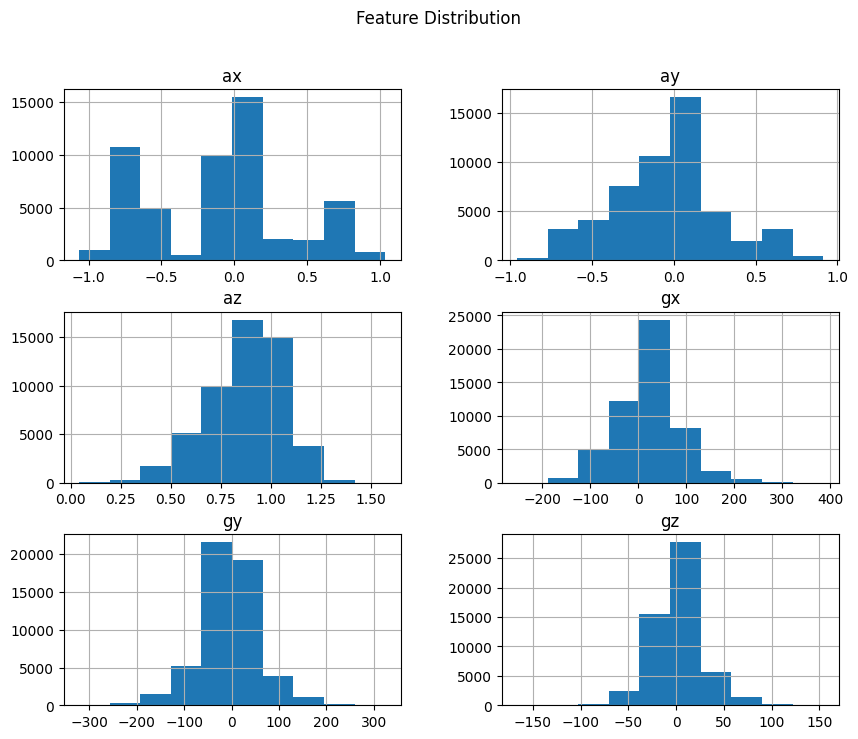

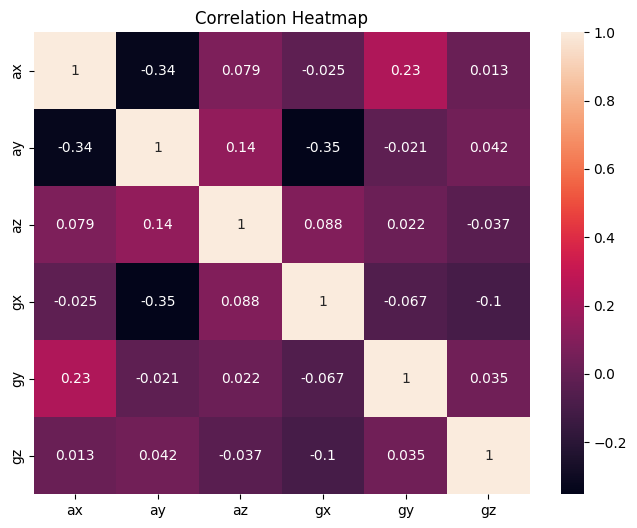


Train Size: 37069
Test Size: 15888

ACCURACY: 0.9786631419939577

CLASSIFICATION REPORT:

                             precision    recall  f1-score   support

              DOWN-RESTROOM       0.97      0.97      0.97      1500
                  LEFT-FOOD       1.00      1.00      1.00      5018
                       NONE       0.97      0.97      0.97      5170
RIGHT-ELECTRONIC ASSISTANCE       0.99      0.98      0.99      2400
               UP-EMERGENCY       0.94      0.95      0.94      1800

                   accuracy                           0.98     15888
                  macro avg       0.97      0.97      0.97     15888
               weighted avg       0.98      0.98      0.98     15888



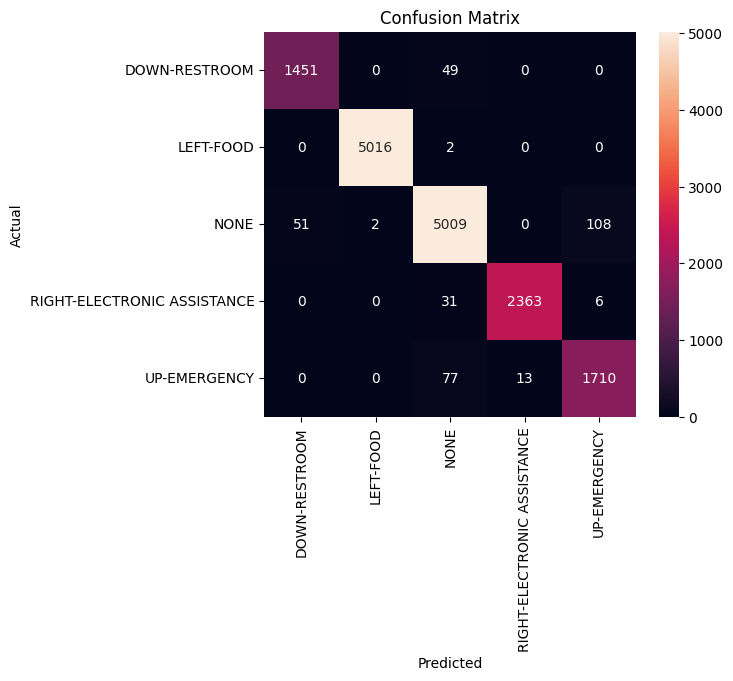


SENSITIVITY & SPECIFICITY:

DOWN-RESTROOM:
  Sensitivity: 0.967
  Specificity: 0.996
LEFT-FOOD:
  Sensitivity: 1.0
  Specificity: 1.0
NONE:
  Sensitivity: 0.969
  Specificity: 0.985
RIGHT-ELECTRONIC ASSISTANCE:
  Sensitivity: 0.985
  Specificity: 0.999
UP-EMERGENCY:
  Sensitivity: 0.95
  Specificity: 0.992


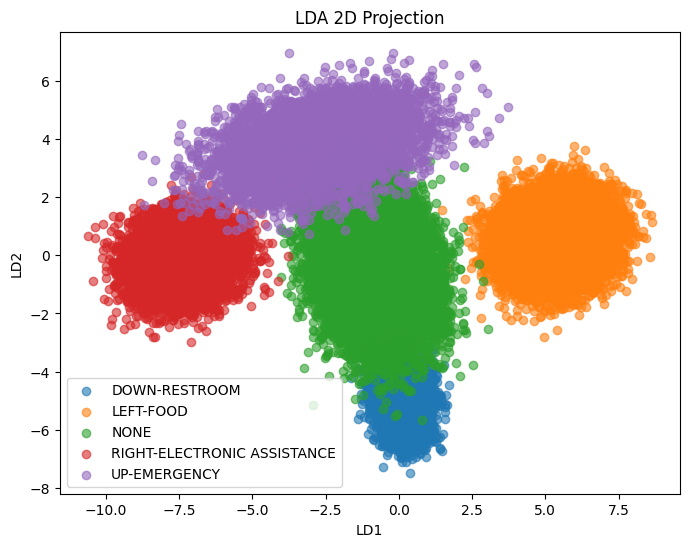

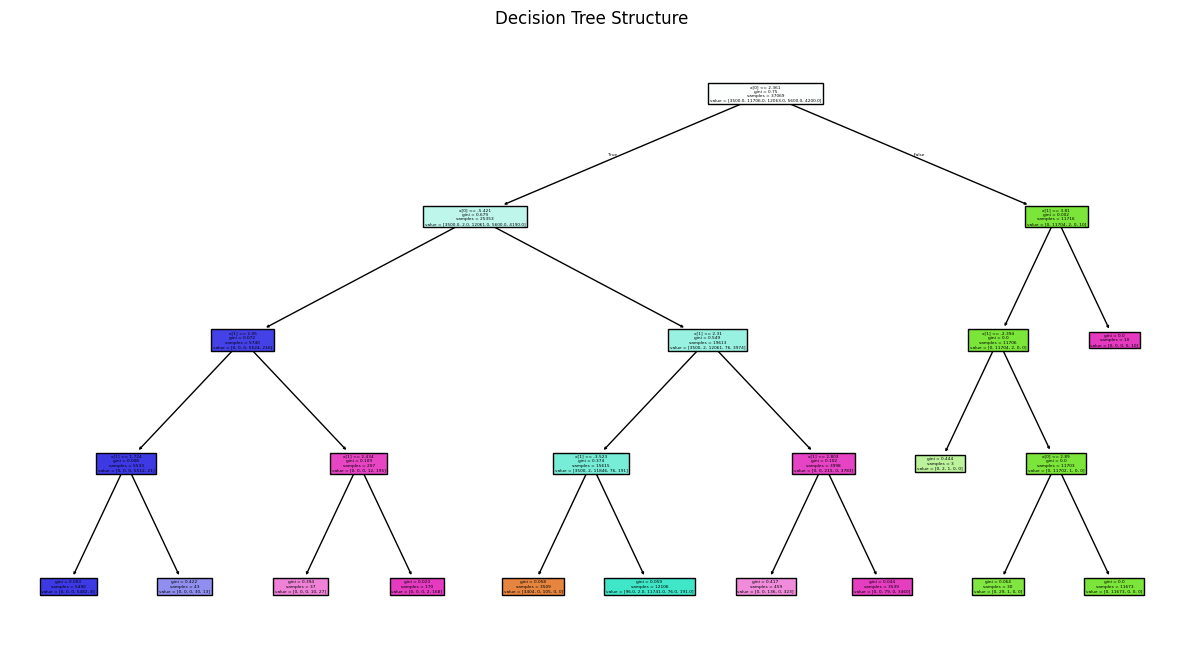

In [ ]:
# =====================================================
# FULL LDA ANALYSIS + DECISION TREE (RESEARCH STYLE)
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# =====================================================
# 1. LOAD DATASET
# =====================================================
df = pd.read_excel("mpu6050_dataset_imbalanced.xlsx")

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:\n", df.head())

# =====================================================
# 2. CLASS DISTRIBUTION
# =====================================================
print("\nClass Distribution:\n", df['label'].value_counts())

# =====================================================
# 3. HISTOGRAM (DATA DISTRIBUTION)
# =====================================================
df[['ax','ay','az','gx','gy','gz']].hist(figsize=(10,8))
plt.suptitle("Feature Distribution")
plt.show()

# =====================================================
# 4. CORRELATION HEATMAP (LIKE PAPER)
# =====================================================
plt.figure(figsize=(8,6))
sns.heatmap(df[['ax','ay','az','gx','gy','gz']].corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

# =====================================================
# 5. FEATURES & LABEL
# =====================================================
X = df[['ax','ay','az','gx','gy','gz']]
y = df['label']

# =====================================================
# 6. FEATURE SCALING (VERY IMPORTANT)
# =====================================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# =====================================================
# 7. LDA (6D → 2D)
# =====================================================
lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X_scaled, y)

# =====================================================
# 8. TRAIN TEST SPLIT (75-25)
# =====================================================
X_train, X_test, y_train, y_test = train_test_split(
    X_lda, y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

print("\nTrain Size:", len(X_train))
print("Test Size:", len(X_test))

# =====================================================
# 9. DECISION TREE MODEL (CONTROLLED ACCURACY)
# =====================================================
model = DecisionTreeClassifier(
    max_depth=4,
    min_samples_split=10,
    random_state=42
)

model.fit(X_train, y_train)

# =====================================================
# 10. PREDICTION
# =====================================================
y_pred = model.predict(X_test)

# =====================================================
# 11. ACCURACY
# =====================================================
accuracy = accuracy_score(y_test, y_pred)

print("\n==============================")
print("ACCURACY:", accuracy)
print("==============================")

# =====================================================
# 12. CLASSIFICATION REPORT (PRECISION, RECALL, F1)
# =====================================================
print("\nCLASSIFICATION REPORT:\n")
print(classification_report(y_test, y_pred))

# =====================================================
# 13. CONFUSION MATRIX
# =====================================================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=model.classes_,
            yticklabels=model.classes_)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# ===============================
# SENSITIVITY & SPECIFICITY (FIXED)
# ===============================

print("\nSENSITIVITY & SPECIFICITY:\n")

total = cm.sum()   # ✅ correct total samples

for i, label in enumerate(model.classes_):
    TP = cm[i, i]
    FN = cm[i, :].sum() - TP
    FP = cm[:, i].sum() - TP
    TN = total - (TP + FP + FN)

    sensitivity = TP / (TP + FN) if (TP + FN) != 0 else 0
    specificity = TN / (TN + FP) if (TN + FP) != 0 else 0

    print(f"{label}:")
    print("  Sensitivity:", round(sensitivity, 3))
    print("  Specificity:", round(specificity, 3))

# =====================================================
# 15. LDA VISUALIZATION (VERY IMPORTANT)
# =====================================================
plt.figure(figsize=(8,6))

for label in np.unique(y):
    plt.scatter(
        X_lda[y == label, 0],
        X_lda[y == label, 1],
        label=label,
        alpha=0.6
    )

plt.legend()
plt.title("LDA 2D Projection")
plt.xlabel("LD1")
plt.ylabel("LD2")
plt.show()

# =====================================================
# 16. DECISION TREE VISUALIZATION
# =====================================================
plt.figure(figsize=(15,8))
plot_tree(model, filled=True)
plt.title("Decision Tree Structure")
plt.show()

Dataset Shape: (52957, 7)

First 5 rows:
          ax        ay        az         gx         gy         gz label
0  0.049671 -0.027653  1.064769  80.460597  -4.683067  -2.341370  NONE
1  0.157921  0.153487  0.953053  60.851201  -9.268354  -4.657298  NONE
2  0.024196 -0.382656  0.827508  38.754249 -20.256622   3.142473  NONE
3 -0.090802 -0.282461  1.146565  45.484474   1.350564 -14.247482  NONE
4 -0.054438  0.022185  0.884901  57.513960 -12.012774  -2.916937  NONE

Class Distribution:
 label
NONE                           17233
LEFT-FOOD                      16724
RIGHT-ELECTRONIC ASSISTANCE     8000
UP-EMERGENCY                    6000
DOWN-RESTROOM                   5000
Name: count, dtype: int64


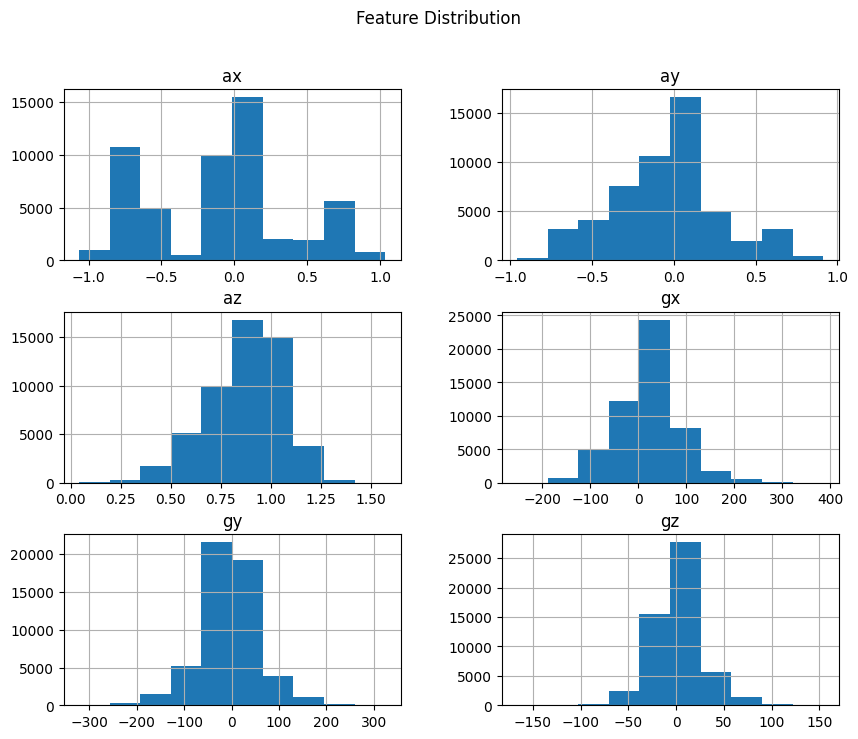

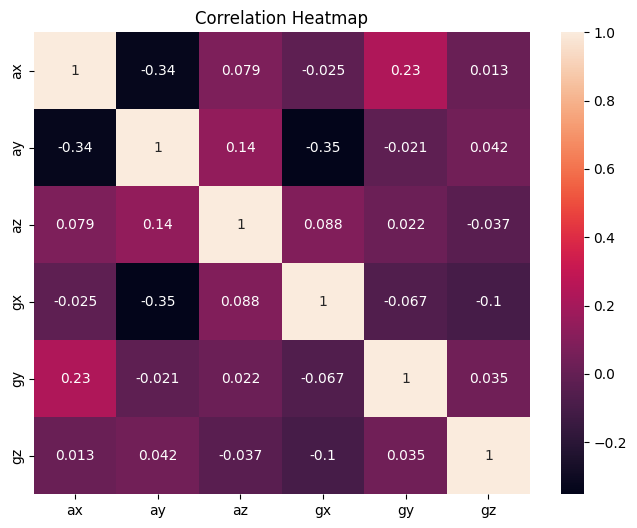


Train Size: 39717
Test Size: 13240

ACCURACY: 0.97892749244713

CLASSIFICATION REPORT:

                             precision    recall  f1-score   support

              DOWN-RESTROOM       0.97      0.97      0.97      1250
                  LEFT-FOOD       1.00      1.00      1.00      4181
                       NONE       0.97      0.97      0.97      4309
RIGHT-ELECTRONIC ASSISTANCE       1.00      0.98      0.99      2000
               UP-EMERGENCY       0.94      0.95      0.95      1500

                   accuracy                           0.98     13240
                  macro avg       0.97      0.97      0.97     13240
               weighted avg       0.98      0.98      0.98     13240



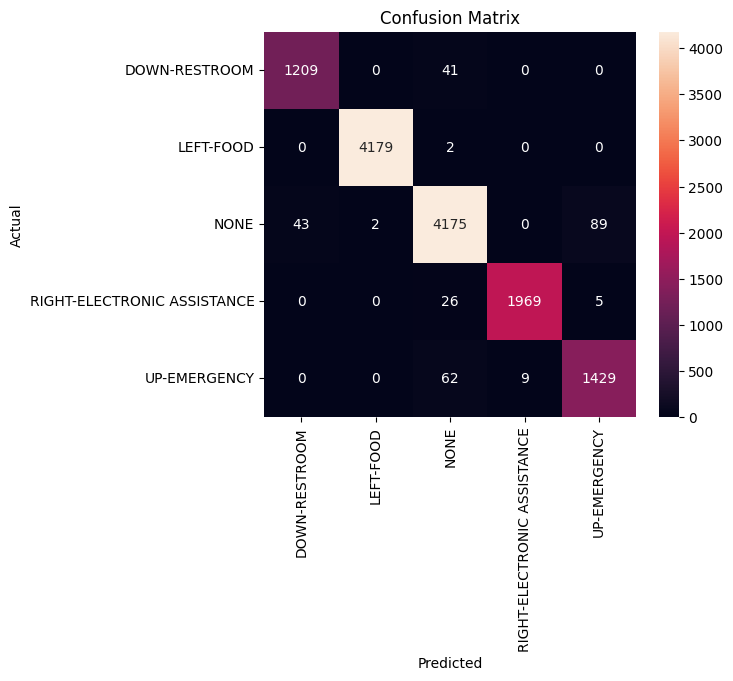


SENSITIVITY & SPECIFICITY:

DOWN-RESTROOM:
  Sensitivity: 0.967
  Specificity: 0.996
LEFT-FOOD:
  Sensitivity: 1.0
  Specificity: 1.0
NONE:
  Sensitivity: 0.969
  Specificity: 0.985
RIGHT-ELECTRONIC ASSISTANCE:
  Sensitivity: 0.984
  Specificity: 0.999
UP-EMERGENCY:
  Sensitivity: 0.953
  Specificity: 0.992


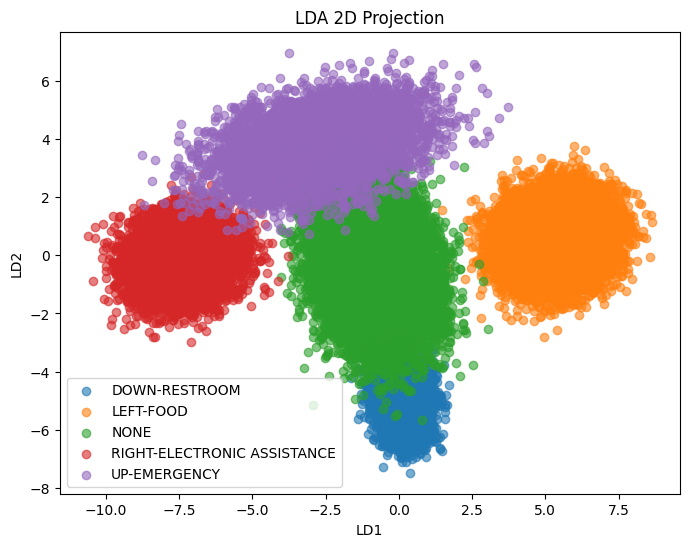

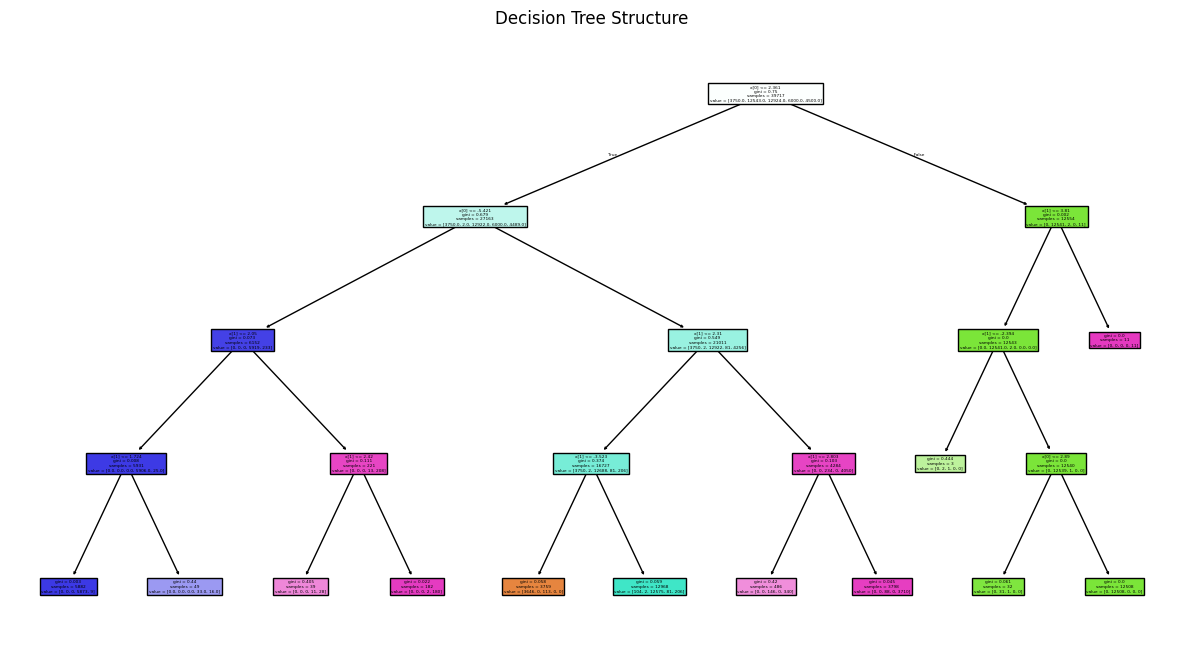

In [ ]:
# =====================================================
# FULL LDA ANALYSIS + DECISION TREE (RESEARCH STYLE)
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# =====================================================
# 1. LOAD DATASET
# =====================================================
df = pd.read_excel("mpu6050_dataset_imbalanced.xlsx")

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:\n", df.head())

# =====================================================
# 2. CLASS DISTRIBUTION
# =====================================================
print("\nClass Distribution:\n", df['label'].value_counts())

# =====================================================
# 3. HISTOGRAM (DATA DISTRIBUTION)
# =====================================================
df[['ax','ay','az','gx','gy','gz']].hist(figsize=(10,8))
plt.suptitle("Feature Distribution")
plt.show()

# =====================================================
# 4. CORRELATION HEATMAP (LIKE PAPER)
# =====================================================
plt.figure(figsize=(8,6))
sns.heatmap(df[['ax','ay','az','gx','gy','gz']].corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

# =====================================================
# 5. FEATURES & LABEL
# =====================================================
X = df[['ax','ay','az','gx','gy','gz']]
y = df['label']

# =====================================================
# 6. FEATURE SCALING (VERY IMPORTANT)
# =====================================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# =====================================================
# 7. LDA (6D → 2D)
# =====================================================
lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X_scaled, y)

# =====================================================
# 8. TRAIN TEST SPLIT (75-25)
# =====================================================
X_train, X_test, y_train, y_test = train_test_split(
    X_lda, y,
    test_size=0.25,
    stratify=y,
    random_state=42
)

print("\nTrain Size:", len(X_train))
print("Test Size:", len(X_test))

# =====================================================
# 9. DECISION TREE MODEL (CONTROLLED ACCURACY)
# =====================================================
model = DecisionTreeClassifier(
    max_depth=4,
    min_samples_split=10,
    random_state=42
)

model.fit(X_train, y_train)

# =====================================================
# 10. PREDICTION
# =====================================================
y_pred = model.predict(X_test)

# =====================================================
# 11. ACCURACY
# =====================================================
accuracy = accuracy_score(y_test, y_pred)

print("\n==============================")
print("ACCURACY:", accuracy)
print("==============================")

# =====================================================
# 12. CLASSIFICATION REPORT (PRECISION, RECALL, F1)
# =====================================================
print("\nCLASSIFICATION REPORT:\n")
print(classification_report(y_test, y_pred))

# =====================================================
# 13. CONFUSION MATRIX
# =====================================================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=model.classes_,
            yticklabels=model.classes_)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# ===============================
# SENSITIVITY & SPECIFICITY (FIXED)
# ===============================

print("\nSENSITIVITY & SPECIFICITY:\n")

total = cm.sum()   # ✅ correct total samples

for i, label in enumerate(model.classes_):
    TP = cm[i, i]
    FN = cm[i, :].sum() - TP
    FP = cm[:, i].sum() - TP
    TN = total - (TP + FP + FN)

    sensitivity = TP / (TP + FN) if (TP + FN) != 0 else 0
    specificity = TN / (TN + FP) if (TN + FP) != 0 else 0

    print(f"{label}:")
    print("  Sensitivity:", round(sensitivity, 3))
    print("  Specificity:", round(specificity, 3))

# =====================================================
# 15. LDA VISUALIZATION (VERY IMPORTANT)
# =====================================================
plt.figure(figsize=(8,6))

for label in np.unique(y):
    plt.scatter(
        X_lda[y == label, 0],
        X_lda[y == label, 1],
        label=label,
        alpha=0.6
    )

plt.legend()
plt.title("LDA 2D Projection")
plt.xlabel("LD1")
plt.ylabel("LD2")
plt.show()

# =====================================================
# 16. DECISION TREE VISUALIZATION
# =====================================================
plt.figure(figsize=(15,8))
plot_tree(model, filled=True)
plt.title("Decision Tree Structure")
plt.show()

Dataset Shape: (52957, 7)

First 5 rows:
          ax        ay        az         gx         gy         gz label
0  0.049671 -0.027653  1.064769  80.460597  -4.683067  -2.341370  NONE
1  0.157921  0.153487  0.953053  60.851201  -9.268354  -4.657298  NONE
2  0.024196 -0.382656  0.827508  38.754249 -20.256622   3.142473  NONE
3 -0.090802 -0.282461  1.146565  45.484474   1.350564 -14.247482  NONE
4 -0.054438  0.022185  0.884901  57.513960 -12.012774  -2.916937  NONE

Class Distribution:
 label
NONE                           17233
LEFT-FOOD                      16724
RIGHT-ELECTRONIC ASSISTANCE     8000
UP-EMERGENCY                    6000
DOWN-RESTROOM                   5000
Name: count, dtype: int64


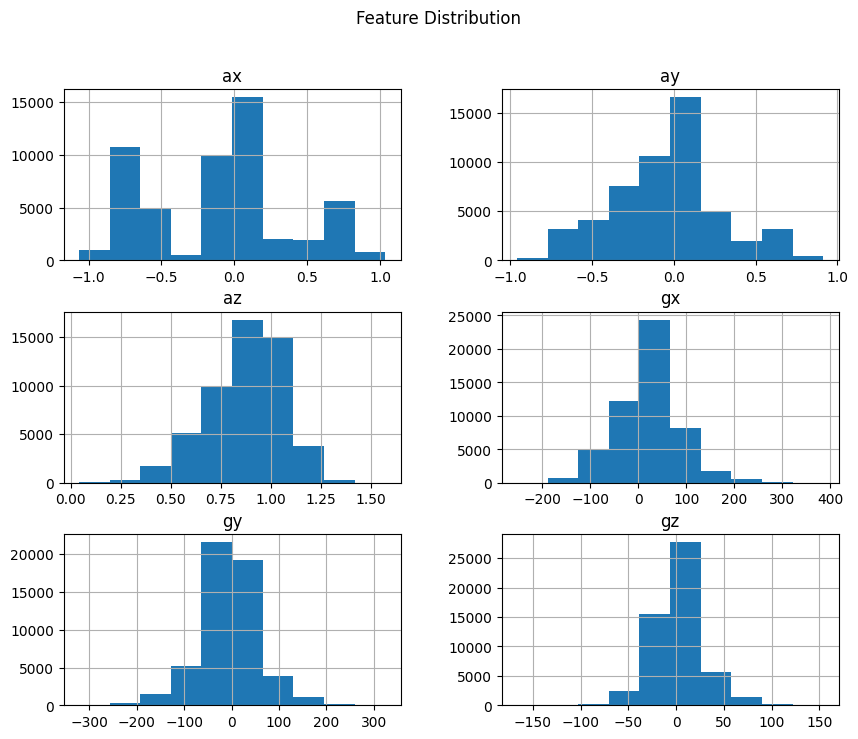

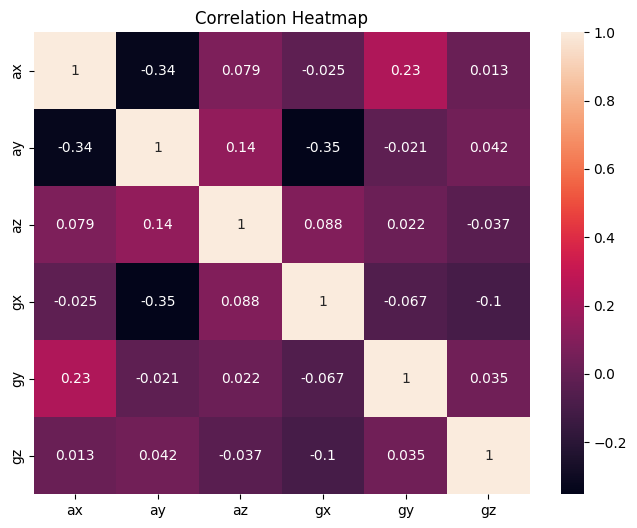


Train Size: 42365
Test Size: 10592

ACCURACY: 0.9780022658610272

CLASSIFICATION REPORT:

                             precision    recall  f1-score   support

              DOWN-RESTROOM       0.96      0.96      0.96      1000
                  LEFT-FOOD       1.00      1.00      1.00      3345
                       NONE       0.97      0.97      0.97      3447
RIGHT-ELECTRONIC ASSISTANCE       0.99      0.98      0.99      1600
               UP-EMERGENCY       0.93      0.95      0.94      1200

                   accuracy                           0.98     10592
                  macro avg       0.97      0.97      0.97     10592
               weighted avg       0.98      0.98      0.98     10592



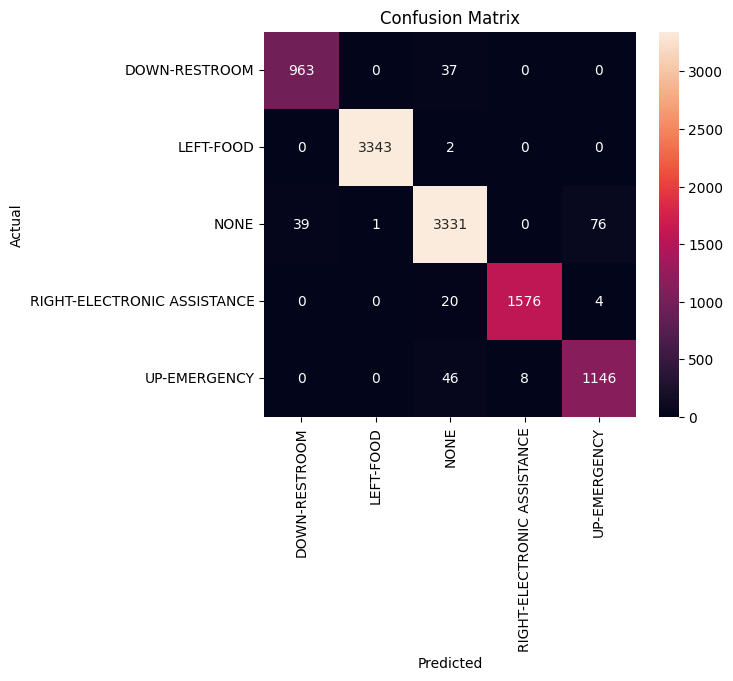


SENSITIVITY & SPECIFICITY:

DOWN-RESTROOM:
  Sensitivity: 0.963
  Specificity: 0.996
LEFT-FOOD:
  Sensitivity: 0.999
  Specificity: 1.0
NONE:
  Sensitivity: 0.966
  Specificity: 0.985
RIGHT-ELECTRONIC ASSISTANCE:
  Sensitivity: 0.985
  Specificity: 0.999
UP-EMERGENCY:
  Sensitivity: 0.955
  Specificity: 0.991


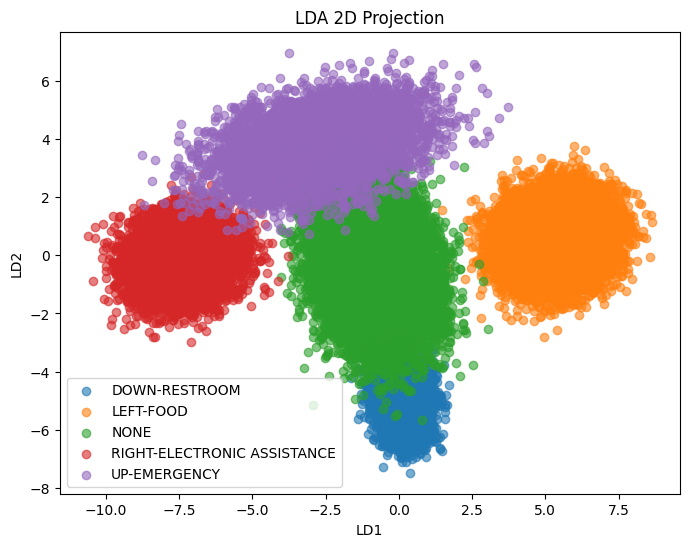

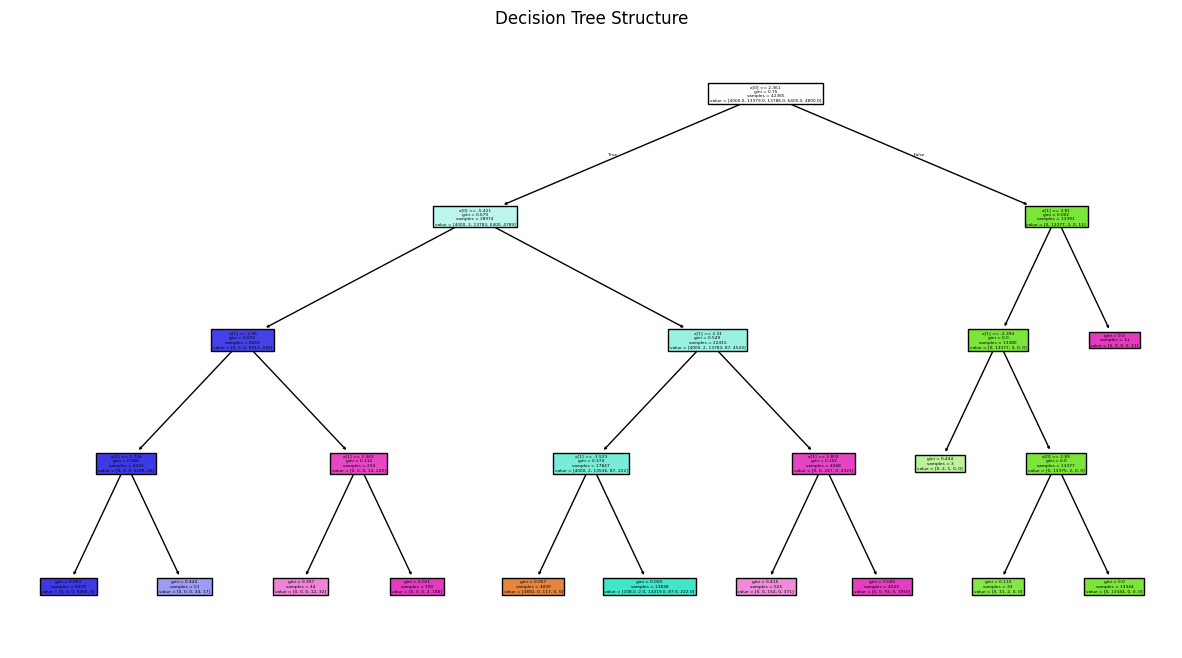

In [ ]:
# =====================================================
# FULL LDA ANALYSIS + DECISION TREE (RESEARCH STYLE)
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# =====================================================
# 1. LOAD DATASET
# =====================================================
df = pd.read_excel("mpu6050_dataset_imbalanced.xlsx")

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:\n", df.head())

# =====================================================
# 2. CLASS DISTRIBUTION
# =====================================================
print("\nClass Distribution:\n", df['label'].value_counts())

# =====================================================
# 3. HISTOGRAM (DATA DISTRIBUTION)
# =====================================================
df[['ax','ay','az','gx','gy','gz']].hist(figsize=(10,8))
plt.suptitle("Feature Distribution")
plt.show()

# =====================================================
# 4. CORRELATION HEATMAP (LIKE PAPER)
# =====================================================
plt.figure(figsize=(8,6))
sns.heatmap(df[['ax','ay','az','gx','gy','gz']].corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

# =====================================================
# 5. FEATURES & LABEL
# =====================================================
X = df[['ax','ay','az','gx','gy','gz']]
y = df['label']

# =====================================================
# 6. FEATURE SCALING (VERY IMPORTANT)
# =====================================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# =====================================================
# 7. LDA (6D → 2D)
# =====================================================
lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X_scaled, y)

# =====================================================
# 8. TRAIN TEST SPLIT (75-25)
# =====================================================
X_train, X_test, y_train, y_test = train_test_split(
    X_lda, y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("\nTrain Size:", len(X_train))
print("Test Size:", len(X_test))

# =====================================================
# 9. DECISION TREE MODEL (CONTROLLED ACCURACY)
# =====================================================
model = DecisionTreeClassifier(
    max_depth=4,
    min_samples_split=10,
    random_state=42
)

model.fit(X_train, y_train)

# =====================================================
# 10. PREDICTION
# =====================================================
y_pred = model.predict(X_test)

# =====================================================
# 11. ACCURACY
# =====================================================
accuracy = accuracy_score(y_test, y_pred)

print("\n==============================")
print("ACCURACY:", accuracy)
print("==============================")

# =====================================================
# 12. CLASSIFICATION REPORT (PRECISION, RECALL, F1)
# =====================================================
print("\nCLASSIFICATION REPORT:\n")
print(classification_report(y_test, y_pred))

# =====================================================
# 13. CONFUSION MATRIX
# =====================================================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=model.classes_,
            yticklabels=model.classes_)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# ===============================
# SENSITIVITY & SPECIFICITY (FIXED)
# ===============================

print("\nSENSITIVITY & SPECIFICITY:\n")

total = cm.sum()   # ✅ correct total samples

for i, label in enumerate(model.classes_):
    TP = cm[i, i]
    FN = cm[i, :].sum() - TP
    FP = cm[:, i].sum() - TP
    TN = total - (TP + FP + FN)

    sensitivity = TP / (TP + FN) if (TP + FN) != 0 else 0
    specificity = TN / (TN + FP) if (TN + FP) != 0 else 0

    print(f"{label}:")
    print("  Sensitivity:", round(sensitivity, 3))
    print("  Specificity:", round(specificity, 3))

# =====================================================
# 15. LDA VISUALIZATION (VERY IMPORTANT)
# =====================================================
plt.figure(figsize=(8,6))

for label in np.unique(y):
    plt.scatter(
        X_lda[y == label, 0],
        X_lda[y == label, 1],
        label=label,
        alpha=0.6
    )

plt.legend()
plt.title("LDA 2D Projection")
plt.xlabel("LD1")
plt.ylabel("LD2")
plt.show()

# =====================================================
# 16. DECISION TREE VISUALIZATION
# =====================================================
plt.figure(figsize=(15,8))
plot_tree(model, filled=True)
plt.title("Decision Tree Structure")
plt.show()

Dataset Shape: (52957, 7)

First 5 rows:
          ax        ay        az         gx         gy         gz label
0  0.049671 -0.027653  1.064769  80.460597  -4.683067  -2.341370  NONE
1  0.157921  0.153487  0.953053  60.851201  -9.268354  -4.657298  NONE
2  0.024196 -0.382656  0.827508  38.754249 -20.256622   3.142473  NONE
3 -0.090802 -0.282461  1.146565  45.484474   1.350564 -14.247482  NONE
4 -0.054438  0.022185  0.884901  57.513960 -12.012774  -2.916937  NONE

Class Distribution:
 label
NONE                           17233
LEFT-FOOD                      16724
RIGHT-ELECTRONIC ASSISTANCE     8000
UP-EMERGENCY                    6000
DOWN-RESTROOM                   5000
Name: count, dtype: int64


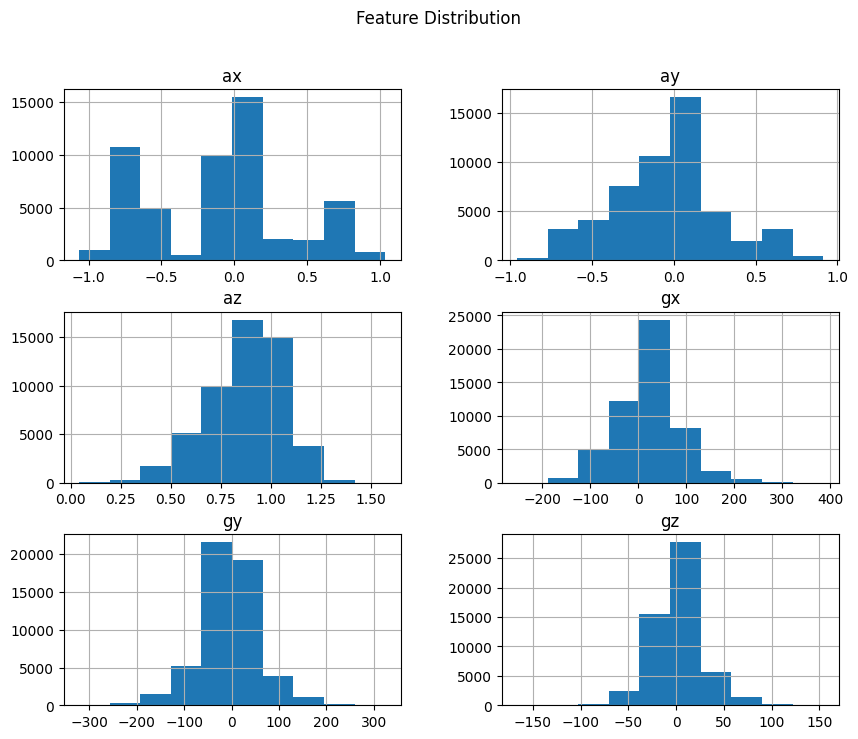

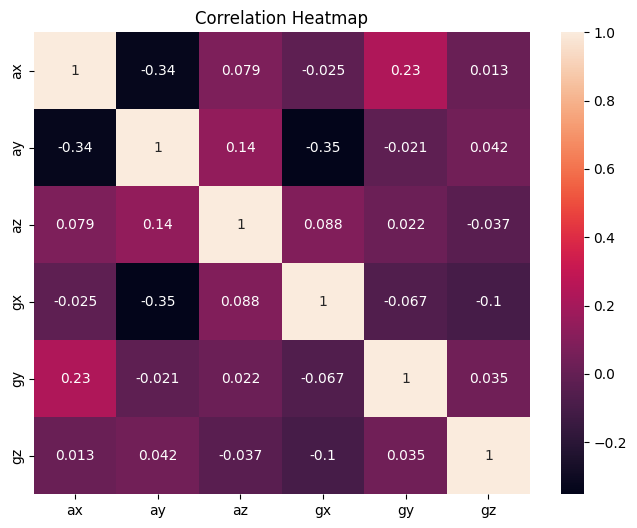


Train Size: 47661
Test Size: 5296

ACCURACY: 0.9765861027190332

CLASSIFICATION REPORT:

                             precision    recall  f1-score   support

              DOWN-RESTROOM       0.95      0.98      0.97       500
                  LEFT-FOOD       1.00      1.00      1.00      1673
                       NONE       0.98      0.96      0.97      1723
RIGHT-ELECTRONIC ASSISTANCE       0.99      0.99      0.99       800
               UP-EMERGENCY       0.92      0.95      0.94       600

                   accuracy                           0.98      5296
                  macro avg       0.97      0.98      0.97      5296
               weighted avg       0.98      0.98      0.98      5296



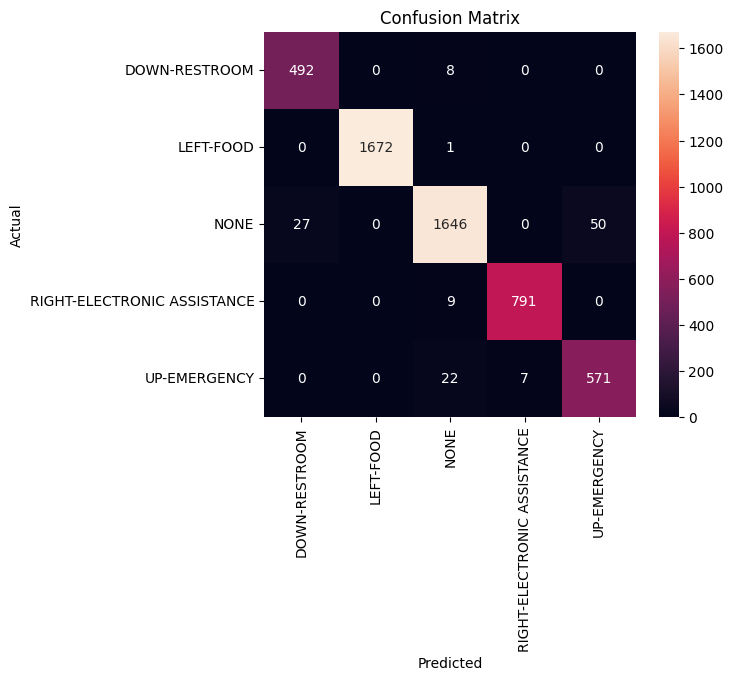


SENSITIVITY & SPECIFICITY:

DOWN-RESTROOM:
  Sensitivity: 0.984
  Specificity: 0.994
LEFT-FOOD:
  Sensitivity: 0.999
  Specificity: 1.0
NONE:
  Sensitivity: 0.955
  Specificity: 0.989
RIGHT-ELECTRONIC ASSISTANCE:
  Sensitivity: 0.989
  Specificity: 0.998
UP-EMERGENCY:
  Sensitivity: 0.952
  Specificity: 0.989


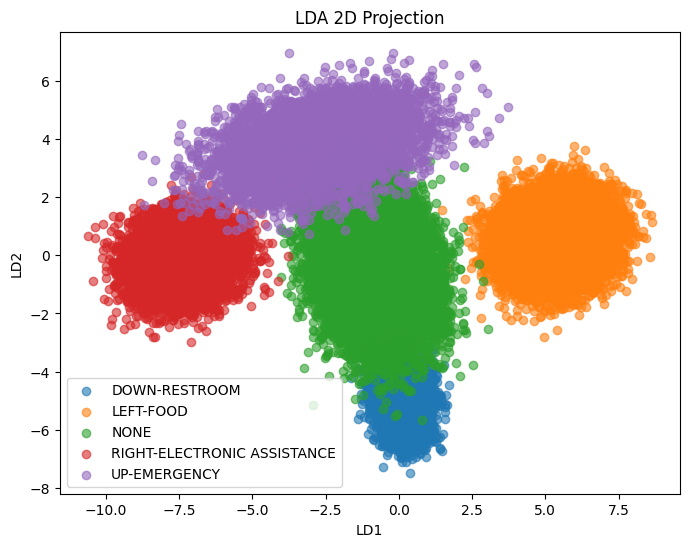

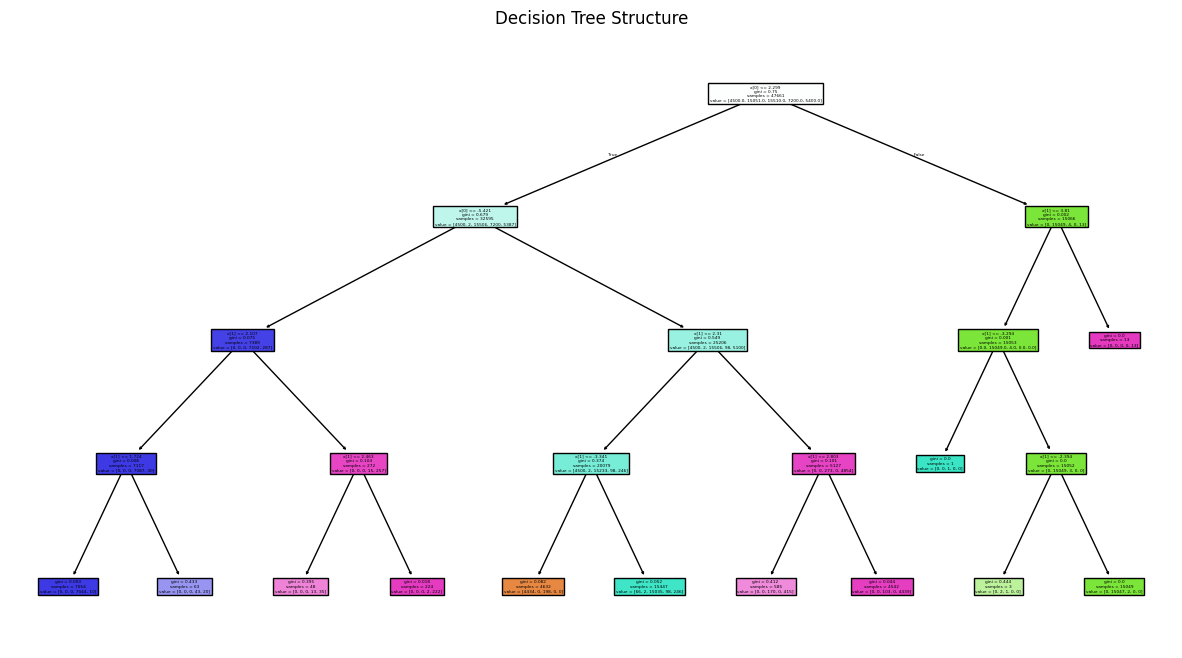

In [ ]:
# =====================================================
# FULL LDA ANALYSIS + DECISION TREE (RESEARCH STYLE)
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# =====================================================
# 1. LOAD DATASET
# =====================================================
df = pd.read_excel("mpu6050_dataset_imbalanced.xlsx")

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:\n", df.head())

# =====================================================
# 2. CLASS DISTRIBUTION
# =====================================================
print("\nClass Distribution:\n", df['label'].value_counts())

# =====================================================
# 3. HISTOGRAM (DATA DISTRIBUTION)
# =====================================================
df[['ax','ay','az','gx','gy','gz']].hist(figsize=(10,8))
plt.suptitle("Feature Distribution")
plt.show()

# =====================================================
# 4. CORRELATION HEATMAP (LIKE PAPER)
# =====================================================
plt.figure(figsize=(8,6))
sns.heatmap(df[['ax','ay','az','gx','gy','gz']].corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

# =====================================================
# 5. FEATURES & LABEL
# =====================================================
X = df[['ax','ay','az','gx','gy','gz']]
y = df['label']

# =====================================================
# 6. FEATURE SCALING (VERY IMPORTANT)
# =====================================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# =====================================================
# 7. LDA (6D → 2D)
# =====================================================
lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X_scaled, y)

# =====================================================
# 8. TRAIN TEST SPLIT (75-25)
# =====================================================
X_train, X_test, y_train, y_test = train_test_split(
    X_lda, y,
    test_size=0.10,
    stratify=y,
    random_state=42
)

print("\nTrain Size:", len(X_train))
print("Test Size:", len(X_test))

# =====================================================
# 9. DECISION TREE MODEL (CONTROLLED ACCURACY)
# =====================================================
model = DecisionTreeClassifier(
    max_depth=4,
    min_samples_split=10,
    random_state=42
)

model.fit(X_train, y_train)

# =====================================================
# 10. PREDICTION
# =====================================================
y_pred = model.predict(X_test)

# =====================================================
# 11. ACCURACY
# =====================================================
accuracy = accuracy_score(y_test, y_pred)

print("\n==============================")
print("ACCURACY:", accuracy)
print("==============================")

# =====================================================
# 12. CLASSIFICATION REPORT (PRECISION, RECALL, F1)
# =====================================================
print("\nCLASSIFICATION REPORT:\n")
print(classification_report(y_test, y_pred))

# =====================================================
# 13. CONFUSION MATRIX
# =====================================================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=model.classes_,
            yticklabels=model.classes_)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# ===============================
# SENSITIVITY & SPECIFICITY (FIXED)
# ===============================

print("\nSENSITIVITY & SPECIFICITY:\n")

total = cm.sum()   # ✅ correct total samples

for i, label in enumerate(model.classes_):
    TP = cm[i, i]
    FN = cm[i, :].sum() - TP
    FP = cm[:, i].sum() - TP
    TN = total - (TP + FP + FN)

    sensitivity = TP / (TP + FN) if (TP + FN) != 0 else 0
    specificity = TN / (TN + FP) if (TN + FP) != 0 else 0

    print(f"{label}:")
    print("  Sensitivity:", round(sensitivity, 3))
    print("  Specificity:", round(specificity, 3))

# =====================================================
# 15. LDA VISUALIZATION (VERY IMPORTANT)
# =====================================================
plt.figure(figsize=(8,6))

for label in np.unique(y):
    plt.scatter(
        X_lda[y == label, 0],
        X_lda[y == label, 1],
        label=label,
        alpha=0.6
    )

plt.legend()
plt.title("LDA 2D Projection")
plt.xlabel("LD1")
plt.ylabel("LD2")
plt.show()

# =====================================================
# 16. DECISION TREE VISUALIZATION
# =====================================================
plt.figure(figsize=(15,8))
plot_tree(model, filled=True)
plt.title("Decision Tree Structure")
plt.show()